# The Hubbard dimer from partial spectral functions

The Hubbard atom calculation of `hubbard_atom_spectral_representation.ipynb`, repeated for two sites.
The spectral machinery of

> F. B. Kugler, S.-S. B. Lee and J. von Delft,
> *Multipoint Correlation Functions: Spectral Representation and Numerical Evaluation*,
> [Phys. Rev. X **11**, 041006 (2021)](https://doi.org/10.1103/PhysRevX.11.041006)

is reused unchanged: PSFs from Eq. (28), the Matsubara kernel Eq. (46), the Keldysh kernels Eqs. (52), (67b)
and assembly Eq. (67a). Only the Hamiltonian, the operators and the momentum bookkeeping of the vertex are new.

**What the dimer tests that the atom could not.**
1. *Nonlocal operators.* Eq. (28) is a Lehmann sum over arbitrary operators $\mathcal O^i$; locality enters the
   paper only from Sec. III on. Here the operators are site and momentum combinations.
2. *Momentum.* A selection rule, $k_1-k_2+k_3-k_4\equiv 0 \pmod{2\pi}$, that a single site cannot have.
3. *A nondegenerate singlet ground state* instead of the atom's free-moment doublet. That changes what the
   $\beta\delta_\omega$ terms of Eq. (85) do (D11).

**Provenance.** No paper in the project treats the dimer. The closed forms used as benchmarks (spectrum, $Z$,
$G_k$) come from the task sheet; this notebook checks them against a 16-state exact diagonalisation rather
than assuming them. Every equation cited from the paper was read from the rendered page image, not the PDF
text layer.

| Check | Content | Result |
|:--|:--|:--|
| **D1** | spectrum and $Z$ | ≤ 5e-15 |
| **D2** | $G_k(i\nu)$ from the $\ell=2$ PSFs vs the closed form | ≤ 4e-15 |
| **D3** | $G_{11}$, $G_{12}$ from site operators | ≤ 1e-15; $G_{11}$ purely imaginary |
| **D4** | Keldysh $\ell=2$: $G^R$, $G^A$; FDT (C4) at every pole | ≤ 1e-13 relative; $O(\gamma_0^2)$ |
| **D5** | momentum selection rule, 8 forbidden tuples | exactly 0; ≤ 8e-16 unfiltered |
| **D6** | $U=0$ null test | ≤ 3e-14 |
| **D7** | $F/U \to \tfrac12\delta_{k_1-k_2+k_3-k_4}$ | ≤ 6e-6 at $U \le 10^{-2}$ |
| **D8** | $t\to0$: $F\to\tfrac12 F^{\rm atom}\delta$; the two branches of Eq. (46) | exact at $t=0$; $\propto t^2$ for $t\ge10^{-3}$; roundoff $\propto 1/t^2$ below |
| **D9** | crossing symmetry and SU(2) | ≤ 5e-14 |
| **D10** | Keldysh: D5, D6, Eq. (69) | exact / ≤ 5e-14 / exact |
| **D11** | size of the $\delta_{\omega_{12},0}$ term vs $\beta(c-U/2)$ | cut off as $e^{-\beta(c-U/2)}$ |

The test suite (`julia --project test/runtests.jl`) runs the same checks as assertions. Every cell below
runs in a few seconds; the whole notebook takes about a minute.

*Running on Colab:* the first cell includes `../src/HubbardAtom.jl`, which pulls in every file of `src/`
(`psf.jl`, `kernel.jl`, `correlator.jl`, `keldysh.jl`, `dimer.jl`, `heatmap.jl`). Upload all seven files and point
the `include` at them, or clone the repository; `src/` needs the `StaticArrays` package (`Pkg.add("StaticArrays")`).

In [1]:
include(joinpath(@__DIR__, "..", "src", "HubbardAtom.jl"))
using .HubbardAtom
using LinearAlgebra
using Printf

## Model and operators

$$
H=-t\sum_\sigma\bigl(c^\dagger_{1\sigma}c_{2\sigma}+c^\dagger_{2\sigma}c_{1\sigma}\bigr)
+U\sum_{i=1,2}n_{i\uparrow}n_{i\downarrow}-\frac U2\sum_{i\sigma}n_{i\sigma},
\qquad
c_{k\sigma}=\tfrac{1}{\sqrt2}\bigl(c_{1\sigma}+e^{ik}c_{2\sigma}\bigr),\quad k\in\{0,\pi\}.
$$

The last term of $H$ puts the chemical potential at half filling, as $\varepsilon_d=-U/2$ did for the atom.
This is Eq. (80) of the paper, restricted to two sites, plus that shift. With hopping $-t$, $k=0$ is the bonding
orbital (energy $-t$) and $k=\pi$ the antibonding one ($+t$). Momenta are carried as an integer $q$ with
$k=q\pi$, so the selection rule is the exact test `iseven(q₁+q₂+q₃+q₄)`.

The four modes are ordered $1{\uparrow},1{\downarrow},2{\uparrow},2{\downarrow}$ and built with global
Jordan–Wigner strings. The hopping term $c^\dagger_{1\uparrow}c_{2\uparrow}$ crosses mode $1{\downarrow}$ and
carries its string sign. It gets that sign automatically because $H$ is formed as a product of the mode
matrices; no matrix element is entered by hand.

**First, before anything else, the canonical anticommutators.**

In [2]:
m = HubbardDimerModel(0.7, 2.3, 3.0)
ops = operators(m)
I16 = Matrix(1.0I, 16, 16)
car = maximum(max(norm(ops.c[a]*ops.c[b]' + ops.c[b]'*ops.c[a] - (a == b)*I16),
                  norm(ops.c[a]*ops.c[b] + ops.c[b]*ops.c[a])) for a in 1:4, b in 1:4)
@printf("{c_i, c_j†} = δ_ij and {c_i, c_j} = 0 for all four modes:   max deviation %.1e\n", car)

bad = jordan_wigner(4; strings = false)          # the same construction without strings
@printf("without Jordan–Wigner strings, ‖{c_1↑, c_2↑}‖ = %.2f   <- the assertion catches this\n\n",
        norm(bad[1]*bad[3] + bad[3]*bad[1]))

P = site_exchange(ops)
@printf("[H, N] = %.1e   [H, Sz] = %.1e   [H, P] = %.1e   (P = site exchange 1 ↔ 2)\n",
        norm(ops.H*ops.N - ops.N*ops.H), norm(ops.H*ops.Sz - ops.Sz*ops.H), norm(ops.H*P - P*ops.H))
@printf("P c_1σ P = c_2σ: %s    P c_0σ P = c_0σ: %s    P c_πσ P = -c_πσ: %s\n",
        P*site_op(ops,1,:up)*P ≈ site_op(ops,2,:up), P*momentum_op(ops,0,:up)*P ≈ momentum_op(ops,0,:up),
        P*momentum_op(ops,1,:up)*P ≈ -momentum_op(ops,1,:up))

{c_i, c_j†} = δ_ij and {c_i, c_j} = 0 for all four modes:   max deviation 0.0e+00
without Jordan–Wigner strings, ‖{c_1↑, c_2↑}‖ = 4.00   <- the assertion catches this



[H, N] = 0.0e+00   [H, Sz] = 0.0e+00   [H, P] = 1.6e-15   (P = site exchange 1 ↔ 2)
P c_1σ P = c_2σ: true    P c_0σ P = c_0σ: true    P c_πσ P = -c_πσ: true


## D1 — spectrum and partition function

With $c\equiv\sqrt{U^2/4+4t^2}$ and $\alpha_\pm\equiv\tfrac12(1\pm2t/c)$, the only nontrivial block is the pair of
$N=2$ spin singlets (covalent and symmetric-ionic), with eigenvalues $U/2\pm c$ before the $-UN/2$ shift. The
closed forms to reproduce:

$$Z=3+3e^{\beta U}+8e^{\beta U/2}\cosh\beta t+2e^{\beta U/2}\cosh\beta c.$$

At large $\beta$, $e^{\beta U}$ and $\cosh\beta c$ overflow. The Boltzmann weights are therefore formed with
energies measured from $E_0=-U/2-c$. Every exponent of $Ze^{\beta E_0}$ is then $\le0$, because $c\ge U/2$ and
$c\ge2|t|$.

In [3]:
for (t, U, β) in [(0.7, 2.3, 3.0), (0.3, 4.0, 10.0), (1.0, 0.5, 1.0)]
    m = HubbardDimerModel(t, U, β); sp = spectrum(m)
    @printf("(t, U, β) = (%.1f, %.1f, %.0f)\n", t, U, β)
    names = ["N=2 singlet (ground)", "N=2 triplet", "N=1,3 bonding", "N=1,3 antibonding",
             "N=0, N=4, ionic singlet", "N=2 excited singlet"]
    for ((E, d), name) in zip(dimer_levels_analytic(m), names)
        found = count(x -> abs(x - E) < 1e-9, sp.E)
        @printf("   %-24s E = %+8.5f   degeneracy %d, found %d\n", name, E, d, found)
    end
    lev = sort(vcat([fill(E, d) for (E, d) in dimer_levels_analytic(m)]...))
    @printf("   max |E - E_exact| = %.1e    |Z/Z_exact - 1| = %.1e\n\n",
            maximum(abs, sp.E - lev), abs(sp.Z / dimer_partition_function_analytic(m) - 1))
end
m = HubbardDimerModel(0.3, 4.0, 1000.0)
@printf("β = 1000:  Z = %s,  Z e^{βE₀} = %.6f,  all ρ finite: %s\n",
        dimer_partition_function_analytic(m), dimer_partition_function_analytic(m; shifted = true),
        all(isfinite, spectrum(m).ρ))

(t, U, β) = (0.7, 2.3, 3)
   N=2 singlet (ground)     E = -2.96177   degeneracy 1, found 1


   N=2 triplet              E = -2.30000   degeneracy 3, found 3
   N=1,3 bonding            E = -1.85000   degeneracy 4, found 4
   N=1,3 antibonding        E = -0.45000   degeneracy 4, found 4
   N=0, N=4, ionic singlet  E = +0.00000   degeneracy 3, found 3
   N=2 excited singlet      E = +0.66177   degeneracy 1, found 1
   max |E - E_exact| = 2.4e-15    |Z/Z_exact - 1| = 2.4e-15



(t, U, β) = (0.3, 4.0, 10)
   N=2 singlet (ground)     E = -4.08806   degeneracy 1, found 1
   N=2 triplet              E = -4.00000   degeneracy 3, found 3
   N=1,3 bonding            E = -2.30000   degeneracy 4, found 4
   N=1,3 antibonding        E = -1.70000   degeneracy 4, found 4
   N=0, N=4, ionic singlet  E = +0.00000   degeneracy 3, found 3
   N=2 excited singlet      E = +0.08806   degeneracy 1, found 1
   max |E - E_exact| = 4.4e-15    |Z/Z_exact - 1| = 3.1e-15

(t, U, β) = (1.0, 0.5, 1)
   N=2 singlet (ground)     E = -2.26556   degeneracy 1, found 1
   N=2 triplet              E = -0.50000   degeneracy 3, found 3
   N=1,3 bonding            E = -1.25000   degeneracy 4, found 4
   N=1,3 antibonding        E = +0.75000   degeneracy 4, found 4
   N=0, N=4, ionic singlet  E = +0.00000   degeneracy 3, found 3
   N=2 excited singlet      E = +1.76556   degeneracy 1, found 1
   max |E - E_exact| = 4.0e-15    |Z/Z_exact - 1| = 1.4e-15

β = 1000:  Z = Inf,  Z e^{βE₀} = 1.000000,  a

## D2 — the propagator $G_k(i\nu)$

Four poles contribute to $G_{k=0}$:

$$
G_{k=0}(i\nu)=\frac1Z\Bigl\{2e^{\beta U/2}(\cosh\beta t+\cosh\beta c)
\Bigl[\frac{\alpha_+}{i\nu-(t-c)}+\frac{\alpha_-}{i\nu-(t+c)}\Bigr]
+\tfrac32\bigl(1+e^{\beta U}+2e^{\beta U/2}\cosh\beta t\bigr)
\Bigl[\frac{1}{i\nu-(U/2-t)}+\frac{1}{i\nu+(U/2+t)}\Bigr]\Bigr\},
$$

and particle–hole symmetry gives $G_{k=\pi}(i\nu)=-G_{k=0}(-i\nu)$. The computed side is Eq. (39) with
$\mathcal O=(c_{k\sigma},c^\dagger_{k\sigma})$, the same $\ell=2$ code as for the atom. The closed form is
evaluated with the $E_0$ shift as well.

**Trap 1.** A wrong hopping sign leaves the spectrum and $Z$ unchanged, because the spectrum is even in $t$. It
exchanges $G_0$ and $G_\pi$, though, and D2 catches that.

In [4]:
for (t, U, β) in [(0.7, 2.3, 3.0), (0.3, 4.0, 10.0), (1.0, 0.5, 1.0)]
    m = HubbardDimerModel(t, U, β); ctx = DimerContext(m)
    e = maximum(abs(dimer_propagator(ctx, q, fermionic_freq(n); σ = σ) - dimer_propagator_exact(m, q, fermionic_freq(n)))
                for q in 0:1, n in -6:5, σ in (:up, :dn))
    @printf("(t, U, β) = (%.1f, %.1f, %4.1f):  max |G_k - closed form| over k ∈ {0,π}, n = -6…5, both spins = %.1e\n",
            t, U, β, e)
end

println("\nlimits of the closed form, each derivable by hand:")
m = HubbardDimerModel(0.8, 0.0, 2.0)
@printf("   U = 0:   G₀(0.3i) = %s,   1/(0.3i + t) = %s\n", round(dimer_propagator_exact(m, 0, 0.3im); digits=12), round(1/(0.3im + 0.8); digits=12))
m = HubbardDimerModel(0.0, 2.6, 4.0)
@printf("   t = 0:   G₀(0.7i) = %s,   atom ½Σ±(iν ± U/2)⁻¹ = %s\n", round(dimer_propagator_exact(m, 0, 0.7im); digits=12),
        round(0.5*(1/(0.7im + 1.3) + 1/(0.7im - 1.3)); digits=12))
m = HubbardDimerModel(0.4, 2.0, 200.0); αp, αm = dimer_alpha(m); c = dimer_c(m)
@printf("   T → 0:   G₀(0.5i) = %s,   α₊/(iν-(t-c)) + α₋/(iν-(t+c)) = %s\n", round(dimer_propagator_exact(m, 0, 0.5im); digits=12),
        round(αp/(0.5im - (0.4 - c)) + αm/(0.5im - (0.4 + c)); digits=12))
m = HubbardDimerModel(0.7, 2.3, 3.0)
@printf("   sum rule: z G₀(z) at z = 10⁷i → %.8f\n", real(1e7im * dimer_propagator_exact(m, 0, 1e7im)))

mw = HubbardDimerModel(-0.7, 2.3, 3.0); cw = DimerContext(mw); ν = fermionic_freq(0)
println("\ntrap 1, hopping sign flipped (t → -t):")
@printf("   spectrum unchanged: %s\n", spectrum(mw).E ≈ spectrum(m).E)
@printf("   |G₀(-t) - G₀ closed form| = %.3f   <- D2 fails\n", abs(dimer_propagator(cw, 0, ν) - dimer_propagator_exact(m, 0, ν)))
@printf("   |G₀(-t) - G_π closed form| = %.1e  <- because G₀ and G_π were exchanged\n", abs(dimer_propagator(cw, 0, ν) - dimer_propagator_exact(m, 1, ν)))

(t, U, β) = (0.7, 2.3,  3.0):  max |G_k - closed form| over k ∈ {0,π}, n = -6…5, both spins = 8.3e-16
(t, U, β) = (0.3, 4.0, 10.0):  max |G_k - closed form| over k ∈ {0,π}, n = -6…5, both spins = 3.2e-15


(t, U, β) = (1.0, 0.5,  1.0):  max |G_k - closed form| over k ∈ {0,π}, n = -6…5, both spins = 1.8e-16

limits of the closed form, each derivable by hand:
   U = 0:   G₀(0.3i) = 1.095890410959 - 0.41095890411im,   1/(0.3i + t) = 1.095890410959 - 0.41095890411im


   t = 0:   G₀(0.7i) = 0.0 - 0.321100917431im,   atom ½Σ±(iν ± U/2)⁻¹ = 0.0 - 0.321100917431im
   T → 0:   G₀(0.5i) = 0.595007770624 - 0.426591392052im,   α₊/(iν-(t-c)) + α₋/(iν-(t+c)) = 0.595007770624 - 0.426591392052im
   sum rule: z G₀(z) at z = 10⁷i → 1.00000000

trap 1, hopping sign flipped (t → -t):
   spectrum unchanged: true


   |G₀(-t) - G₀ closed form| = 0.532   <- D2 fails
   |G₀(-t) - G_π closed form| = 6.7e-16  <- because G₀ and G_π were exchanged


## D3 — local and nonlocal propagators

$G_{11}=\tfrac12(G_0+G_\pi)$ and $G_{12}=\tfrac12(G_0-G_\pi)$, both computed directly from the site operators
$\mathcal O=(c_{i\sigma},c^\dagger_{j\sigma})$ rather than from $G_k$. By particle–hole symmetry $G_{11}(i\nu)$ is
purely imaginary on the Matsubara axis; $G_{12}$ comes out purely real.

In [5]:
for (t, U, β) in [(0.7, 2.3, 3.0), (0.3, 4.0, 10.0), (1.0, 0.5, 1.0)]
    ctx = DimerContext(HubbardDimerModel(t, U, β))
    e11 = e12 = r11 = 0.0
    for n in -4:3
        ν = fermionic_freq(n)
        G0, Gπ = dimer_propagator(ctx, 0, ν), dimer_propagator(ctx, 1, ν)
        G11, G12 = dimer_site_propagator(ctx, 1, 1, ν), dimer_site_propagator(ctx, 1, 2, ν)
        e11 = max(e11, abs(G11 - (G0 + Gπ)/2)); e12 = max(e12, abs(G12 - (G0 - Gπ)/2)); r11 = max(r11, abs(real(G11)))
    end
    ν = fermionic_freq(0)
    @printf("(%.1f, %.1f, %4.1f):  |G₁₁ - ½(G₀+G_π)| = %.1e   |G₁₂ - ½(G₀-G_π)| = %.1e   max|Re G₁₁| = %.1e   G₁₂(iν₀) = %+.4f %+.1ei\n",
            t, U, β, e11, e12, r11, real(dimer_site_propagator(ctx, 1, 2, ν)), imag(dimer_site_propagator(ctx, 1, 2, ν)))
end

(0.7, 2.3,  3.0):  |G₁₁ - ½(G₀+G_π)| = 1.7e-16   |G₁₂ - ½(G₀-G_π)| = 6.5e-17   max|Re G₁₁| = 8.1e-17   G₁₂(iν₀) = +0.2660 -6.1e-17i
(0.3, 4.0, 10.0):  |G₁₁ - ½(G₀+G_π)| = 5.8e-17   |G₁₂ - ½(G₀-G_π)| = 5.0e-17   max|Re G₁₁| = 2.4e-15   G₁₂(iν₀) = +0.0509 -1.1e-16i


(1.0, 0.5,  1.0):  |G₁₁ - ½(G₀+G_π)| = 8.4e-17   |G₁₂ - ½(G₀-G_π)| = 5.2e-17   max|Re G₁₁| = 4.9e-17   G₁₂(iν₀) = +0.0913 -5.0e-17i


## D4 — Keldysh, $\ell=2$

Per App. C, for $\ell=2$ the prefactor of Eq. (67a) is 1 and $G^{[1]}=G^R$, $G^{[2]}=G^A$, $G^{[12]}=G^K$.
The closed form continued as $i\nu\to\omega\pm i\gamma_0$ must reproduce $G^R$ and $G^A$ from Eq. (67). The
fluctuation–dissipation theorem (C4), $G^K=(G^R-G^A)\tanh(\beta\omega/2)$ for fermions, is checked at each pole
of each momentum component. At finite $\gamma_0$ it holds only up to $O(\gamma_0^2)$, as on the atom.

In [6]:
for (t, U, β) in [(0.7, 2.3, 3.0), (0.3, 4.0, 10.0), (1.0, 0.5, 1.0)]
    m = HubbardDimerModel(t, U, β); ctx = DimerContext(m); c = dimer_c(m)
    @printf("(t, U, β) = (%.1f, %.1f, %4.1f)\n", t, U, β)
    for q in 0:1
        A = momentum_op(ctx.ops, q, :up); Os = (A, permutedims(A)); cache = dimer_psf_cache(ctx, (:k, q, :up))
        G(ω, k, g) = keldysh_correlator(m, Os, [ω, -ω], k; γ0 = g, sp = ctx.sp, cache = cache)
        rel = maximum(max(abs(G(ω, [1], 0.05) - dimer_propagator_exact(m, q, ω + 0.05im)) / abs(G(ω, [1], 0.05)),
                          abs(G(ω, [2], 0.05) - dimer_propagator_exact(m, q, ω - 0.05im)) / abs(G(ω, [2], 0.05)))
                      for ω in range(-3, 3; length = 13))
        @printf("   k = %s:  G^R, G^A vs closed form at iν → ω ± iγ₀, 13 points: max rel. err %.1e\n", q == 0 ? "0" : "π", rel)
        poles = [t - c, t + c, U/2 - t, -(U/2 + t)] .* (q == 0 ? 1 : -1)
        for E in poles
            errs = [abs(G(E, [1,2], g) / (G(E, [1], g) - G(E, [2], g)) - tanh(β*E/2)) for g in (1e-2, 1e-3, 1e-4)]
            @printf("      FDT at pole ω = %+.3f:  |G^K/(G^R-G^A) - tanh(βω/2)| = %.1e, %.1e, %.1e  (γ₀ = 1e-2, 1e-3, 1e-4)\n", E, errs...)
        end
    end
end

(t, U, β) = (0.7, 2.3,  3.0)
   k = 0:  G^R, G^A vs closed form at iν → ω ± iγ₀, 13 points: max rel. err 2.5e-14


      FDT at pole ω = -1.112:  |G^K/(G^R-G^A) - tanh(βω/2)| = 1.6e-05, 1.6e-07, 1.6e-09  (γ₀ = 1e-2, 1e-3, 1e-4)
      FDT at pole ω = +2.512:  |G^K/(G^R-G^A) - tanh(βω/2)| = 1.6e-04, 1.6e-06, 1.6e-08  (γ₀ = 1e-2, 1e-3, 1e-4)
      FDT at pole ω = +0.450:  |G^K/(G^R-G^A) - tanh(βω/2)| = 2.5e-04, 2.5e-06, 2.5e-08  (γ₀ = 1e-2, 1e-3, 1e-4)
      FDT at pole ω = -1.850:  |G^K/(G^R-G^A) - tanh(βω/2)| = 7.4e-05, 7.4e-07, 7.4e-09  (γ₀ = 1e-2, 1e-3, 1e-4)
   k = π:  G^R, G^A vs closed form at iν → ω ± iγ₀, 13 points: max rel. err 7.6e-14
      FDT at pole ω = +1.112:  |G^K/(G^R-G^A) - tanh(βω/2)| = 1.6e-05, 1.6e-07, 1.6e-09  (γ₀ = 1e-2, 1e-3, 1e-4)
      FDT at pole ω = -2.512:  |G^K/(G^R-G^A) - tanh(βω/2)| = 1.6e-04, 1.6e-06, 1.6e-08  (γ₀ = 1e-2, 1e-3, 1e-4)
      FDT at pole ω = -0.450:  |G^K/(G^R-G^A) - tanh(βω/2)| = 2.5e-04, 2.5e-06, 2.5e-08  (γ₀ = 1e-2, 1e-3, 1e-4)
      FDT at pole ω = +1.850:  |G^K/(G^R-G^A) - tanh(βω/2)| = 7.4e-05, 7.4e-07, 7.4e-09  (γ₀ = 1e-2, 1e-3, 1e-4)
(t, U, β) = 

## Four-point objects — what changes

**Disconnected part.** Every Wick contraction $\langle c_{k_a}c^\dagger_{k_b}\rangle$ is diagonal in momentum, so
Eq. (73) (p. 15) gets a Kronecker delta per pairing. For
$\mathcal O=(c_{k_1\sigma},c^\dagger_{k_2\sigma},c_{k_3\sigma'},c^\dagger_{k_4\sigma'})$,

$$G^{\rm dis}=\beta\,G_{k_1}(i\omega_1)G_{k_3}(i\omega_3)\bigl(\delta_{\sigma\sigma'}\delta_{k_1k_4}\delta_{k_2k_3}\delta_{\omega_{23},0}-\delta_{k_1k_2}\delta_{k_3k_4}\delta_{\omega_{12},0}\bigr).$$

It is cross-checked against the kernel-free PSF split of Eq. (31), which needs no momentum bookkeeping at all.

**Amputation in momentum space.** In the site basis the external legs are $2\times2$ matrices $G_{ij}$, so the
scalar division of Eq. (74) is wrong for $t\neq0$ (trap 2, below). In the $k$ basis the propagator is diagonal and
Eq. (74) applies leg by leg:

$$F_{k_1k_2k_3k_4}(i\boldsymbol\omega)=\frac{G^{\rm con}_{k_1k_2k_3k_4}(i\boldsymbol\omega)}{G_{k_1}(i\omega_1)\,G_{k_2}(-i\omega_2)\,G_{k_3}(i\omega_3)\,G_{k_4}(-i\omega_4)},\qquad\omega_4=-\omega_{123}.$$

**Cost, and a matrix-element filter.** A 4p PSF runs over $16^4\times24\approx1.6\times10^6$ eigenstate cycles.
$H$ is not diagonal in the Fock basis here, so rotated matrix elements that a symmetry forbids come out as
roundoff, $\sim10^{-17}$, rather than exact zeros. Kept as they are, 99.9% of the cycles become "nonzero" terms
with weights $\sim10^{-33}$. `DimerContext` therefore zeroes rotated matrix elements below `otol = 1e-12`
before multiplying. A genuine matrix element here is $\gtrsim10^{-3}$ even at $U=5\times10^{-3}$
($\sqrt{\alpha_-}\approx U/8t$), and `otol = 0` gives the unfiltered sum for comparison.

In [7]:
m = HubbardDimerModel(0.7, 2.3, 3.0)
ctx = DimerContext(m)
ctx0 = DimerContext(m; otol = 0.0)
key = (:four, (0,0,0,0), :updn, :full)
n1 = sum(length(d.terms) for d in dimer_psf_cache(ctx, key))
n0 = sum(length(d.terms) for d in dimer_psf_cache(ctx0, key))
@printf("PSF terms of (c₀↑, c†₀↑, c₀↓, c†₀↓), summed over 24 permutations:  %d unfiltered,  %d with otol = 1e-12\n", n0, n1)

M(v...) = MatsubaraFreq.(collect(v))
FREQS = [M(1,3,5,-9), M(1,-1,3,-3), M(1,3,-1,-3), M(1,3,-3,-1), M(1,-1,1,-1), M(3,-1,-3,1)]
FLABEL = ["generic", "ω₁₂=0", "ω₁₃=0", "ω₁₄=0", "ω₁₂=ω₁₄=0", "ω₁₃=0 (b)"]
@printf("filtered vs unfiltered G, 6 frequency points: max |diff| = %.1e\n",
        maximum(abs(dimer_correlator_4p(ctx, (0,0,0,0), :updn, ms) - dimer_correlator_4p(ctx0, (0,0,0,0), :updn, ms)) for ms in FREQS))
empty!(ctx0.cache)

e1 = e2 = 0.0
for qs in all_momentum_tuples(), s in (:updn, :upup), ms in FREQS
    global e1 = max(e1, abs(dimer_correlator_4p(ctx, qs, s, ms; part = :connected) - dimer_connected_4p(ctx, qs, s, ms)))
    global e2 = max(e2, abs(dimer_correlator_4p(ctx, qs, s, ms; part = :disconnected) - dimer_disconnected_4p(ctx, qs, s, ms)))
end
@printf("\nEq. (73) with momentum deltas vs the Eq. (31) PSF split, 16 tuples × 2 spins × 6 points:\n")
@printf("   max |G^con difference| = %.1e    max |G^dis difference| = %.1e\n", e1, e2)

PSF terms of (c₀↑, c†₀↑, c₀↓, c†₀↓), summed over 24 permutations:  397408 unfiltered,  272 with otol = 1e-12
filtered vs unfiltered G, 6 frequency points: max |diff| = 0.0e+00



Eq. (73) with momentum deltas vs the Eq. (31) PSF split, 16 tuples × 2 spins × 6 points:
   max |G^con difference| = 1.5e-15    max |G^dis difference| = 3.0e-15


## D5 — momentum selection rule

Site exchange $P$ maps $c_{0\sigma}\to c_{0\sigma}$ and $c_{\pi\sigma}\to-c_{\pi\sigma}$, and leaves $H$ invariant.
Every correlator with an odd number of $k=\pi$ operators is therefore odd under $P$ and vanishes identically: in
every formalism and every Keldysh component. Equivalently, $F_{k_1k_2k_3k_4}\neq0$ only if
$k_1-k_2+k_3-k_4\equiv0$. This is the first test of how *non-identical* operators enter the permutation sum.

Two columns below: with the matrix-element filter, where forbidden tuples must be exactly zero, and without it,
over all $1.6\times10^6$ cycles, where they must be zero to roundoff.

In [8]:
@printf(" q₁q₂q₃q₄  k₁-k₂+k₃-k₄   max|G| filtered (↑↓, ↑↑)     max|G| unfiltered (↑↓)\n")
for qs in all_momentum_tuples()
    f = [maximum(abs(dimer_correlator_4p(ctx, qs, s, ms)) for ms in FREQS) for s in (:updn, :upup)]
    u0 = maximum(abs(dimer_correlator_4p(ctx0, qs, :updn, ms)) for ms in FREQS)
    empty!(ctx0.cache)                                  # 60 MB per unfiltered tuple: do not keep
    @printf("  %d%d%d%d     %s        %.2e  %.2e              %.2e\n", qs..., momentum_allowed(qs) ? "allowed  " : "FORBIDDEN", f..., u0)
end

 q₁q₂q₃q₄  k₁-k₂+k₃-k₄   max|G| filtered (↑↓, ↑↑)     max|G| unfiltered (↑↓)
  0000     allowed          1.06e+00  4.77e-01              1.06e+00


  0001     FORBIDDEN        0.00e+00  0.00e+00              7.83e-16
  0010     FORBIDDEN        0.00e+00  0.00e+00              6.74e-16


  0011     allowed          1.51e+00  1.03e+00              1.51e+00
  0100     FORBIDDEN        0.00e+00  0.00e+00              6.61e-16


  0101     allowed          5.36e-01  5.61e-02              5.36e-01
  0110     allowed          4.80e-01  1.03e+00              4.80e-01


  0111     FORBIDDEN        0.00e+00  0.00e+00              5.17e-16
  1000     FORBIDDEN        0.00e+00  0.00e+00              6.76e-16


  1001     allowed          4.80e-01  1.03e+00              4.80e-01
  1010     allowed          5.36e-01  5.61e-02              5.36e-01


  1011     FORBIDDEN        0.00e+00  0.00e+00              4.19e-16
  1100     allowed          1.51e+00  1.03e+00              1.51e+00


  1101     FORBIDDEN        0.00e+00  0.00e+00              3.61e-16
  1110     FORBIDDEN        0.00e+00  0.00e+00              3.93e-16


  1111     allowed          1.06e+00  4.77e-01              1.06e+00


## D6 — the $U=0$ null test

At $U=0$ Wick's theorem holds: $G^{\rm con}=0$ and $F=0$ for all 16 $k$ tuples and both spins. The spectrum is
highly degenerate there, so the anomalous branch of Eq. (46) fires on many terms, both in $S$ and in $S^{\rm dis}$,
and must cancel between them. Checked both ways: $G-G^{\rm dis}$ from Eq. (73), and the connected PSF of Eq. (31).

In [9]:
for β in (3.0, 10.0)
    c0 = DimerContext(HubbardDimerModel(0.7, 0.0, β))
    a = maximum(abs(dimer_connected_4p(c0, qs, s, ms)) for qs in all_momentum_tuples(), s in (:updn, :upup), ms in FREQS)
    b = maximum(abs(dimer_correlator_4p(c0, qs, s, ms; part = :connected)) for qs in all_momentum_tuples(), s in (:updn, :upup), ms in FREQS)
    f = maximum(abs(dimer_vertex(c0, qs, s, ms)) for qs in all_momentum_tuples(), s in (:updn, :upup), ms in FREQS)
    g = maximum(abs(dimer_correlator_4p(c0, qs, s, ms)) for qs in all_momentum_tuples(), s in (:updn, :upup), ms in FREQS)
    @printf("U = 0, t = 0.7, β = %4.1f:  max|G - G^dis| = %.1e   max|G[S^con]| = %.1e   max|F| = %.1e   (max|G| = %.2f)\n", β, a, b, f, g)
end

U = 0, t = 0.7, β =  3.0:  max|G - G^dis| = 1.6e-15   max|G[S^con]| = 1.0e-15   max|F| = 1.6e-14   (max|G| = 1.89)
U = 0, t = 0.7, β = 10.0:  max|G - G^dis| = 2.5e-14   max|G[S^con]| = 9.1e-15   max|F| = 8.7e-15   (max|G| = 16.99)


## D7 — first order in $U$

p. 16, below Eq. (84): "the first term $U\delta_{\sigma,\bar\sigma'}$ on the right is the MF bare vertex
$F_{0;\sigma\sigma'}$." Transforming the local $U\delta_{i_1=i_2=i_3=i_4}$ to the $k$ basis,

$$F^{(1)}_{k_1k_2k_3k_4;\uparrow\downarrow}=U\sum_{j=1,2}\tfrac14e^{i(k_1-k_2+k_3-k_4)(j-1)}=\frac U2\,\delta_{k_1-k_2+k_3-k_4\equiv0}.$$

$F/U$ is evaluated at $U=10^{-2}$ and $5\times10^{-3}$ and extrapolated linearly (Richardson) to $U\to0$. The
target is $\tfrac12$ for every allowed tuple and every frequency, 0 for the forbidden ones, and 0 for $\uparrow\uparrow$
(no same-spin bare vertex).

In [10]:
Us = (1e-2, 5e-3)
cs = [DimerContext(HubbardDimerModel(0.7, U, 3.0)) for U in Us]
lim(qs, s, ms) = (v = [dimer_vertex(c, qs, s, ms) / U for (c, U) in zip(cs, Us)]; 2v[2] - v[1])
@printf(" q₁q₂q₃q₄   target   lim F↑↓/U (max|dev| over 6 points)   lim F↑↑/U (max|dev|)\n")
for qs in all_momentum_tuples()
    target = momentum_allowed(qs) ? 0.5 : 0.0
    L = [lim(qs, :updn, ms) for ms in FREQS]
    Luu = [lim(qs, :upup, ms) for ms in FREQS]
    @printf("  %d%d%d%d      %.1f     %+.6f   (%.1e)                      %.1e\n", qs..., target, real(L[1]),
            maximum(abs, L .- target), maximum(abs, Luu))
end

 q₁q₂q₃q₄   target   lim F↑↓/U (max|dev| over 6 points)   lim F↑↑/U (max|dev|)
  0000      0.5     +0.499999   (5.2e-06)                      2.4e-08


  0001      0.0     +0.000000   (0.0e+00)                      0.0e+00
  0010      0.0     +0.000000   (0.0e+00)                      0.0e+00


  0011      0.5     +0.499999   (6.0e-06)                      3.9e-08
  0100      0.0     +0.000000   (0.0e+00)                      0.0e+00
  0101      0.5     +0.499999   (6.1e-06)                      2.5e-08
  0110      0.5     +0.499999   (6.0e-06)                      3.9e-08


  0111      0.0     +0.000000   (0.0e+00)                      0.0e+00
  1000      0.0     +0.000000   (0.0e+00)                      0.0e+00


  1001      0.5     +0.499999   (6.0e-06)                      3.9e-08
  1010      0.5     +0.499999   (6.1e-06)                      2.5e-08
  1011      0.0     +0.000000   (0.0e+00)                      0.0e+00
  1100      0.5     +0.499999   (6.0e-06)                      3.9e-08


  1101      0.0     +0.000000   (0.0e+00)                      0.0e+00
  1110      0.0     +0.000000   (0.0e+00)                      0.0e+00


  1111      0.5     +0.499999   (5.2e-06)                      2.4e-08


## D8 — $t\to0$: the two branches of Eq. (46) against each other

At $t=0$ the sites decouple, the site-basis vertex is $F^{\rm atom}\delta_{i_1=i_2=i_3=i_4}$ with $F^{\rm atom}$ from
Eq. (85), and the transformation of D7 gives $F_{k_1k_2k_3k_4}\to\tfrac12F^{\rm atom}\delta_{k_1-k_2+k_3-k_4\equiv0}$.

At $t=0$ exactly, the $N=1$ bonding and antibonding levels are degenerate and the anomalous branch of Eq. (46)
fires. At small $t\neq0$ the same contribution comes from the regular branch instead, through denominators of order
$2t$. Continuity across $t\to0$ therefore tests the two branches against each other, which the atom alone could
not do. All 16 tuples, both spins, and the six frequency points, including the $\delta$-carrying ones.

In [11]:
U, β = 2.3, 3.0
ma = HubbardAtomModel(U, β)
# PSF terms that take the anomalous branch of Eq. (46), summed over the three single-δ points and both
# spins. Terms with |w| < 1e-8 are skipped: see the note below the table.
function n_anomalous(c, qs)
    n = 0
    for ms in FREQS[2:4], s in (:updn, :upup), d in dimer_psf_cache(c, (:four, qs, s, :full)), t in d.terms
        abs(t.weight) > 1e-8 || continue
        _, van = composites([ms[d.p[i]] for i in 1:4], t.position, c.m.β)
        n += any(van)
    end
    n
end
dev(c, qsset) = maximum(abs(dimer_vertex(c, qs, s, ms) - (momentum_allowed(qs) ? 0.5 * vertex_exact(ma, s, ms) : 0.0))
                        for qs in qsset, s in (:updn, :upup), ms in FREQS)
@printf("   t       max |F - ½F^atom δ|   dev/t² (all)   dev/t² (0101)   dev/t² (0000)   anomalous terms: 0000   0101\n")
for t in (0.0, 1e-1, 1e-2, 1e-3, 3e-4, 1e-4, 3e-5, 1e-5)
    c = DimerContext(HubbardDimerModel(t, U, β))
    e = dev(c, all_momentum_tuples())
    if t == 0
        @printf("  0        %.3e                                                            %3d    %3d\n", e,
                n_anomalous(c, (0,0,0,0)), n_anomalous(c, (0,1,0,1)))
    else
        @printf("  %.0e    %.3e             %8.3f       %10.3f      %9.3f                   %3d    %3d\n", t, e, e/t^2,
                dev(c, [(0,1,0,1)])/t^2, dev(c, [(0,0,0,0)])/t^2, n_anomalous(c, (0,0,0,0)), n_anomalous(c, (0,1,0,1)))
    end
end
@printf("\nscale: max |½F^atom| = %.1f\n", maximum(abs(0.5 * vertex_exact(ma, s, ms)) for s in (:updn, :upup), ms in FREQS))

   t       max |F - ½F^atom δ|   dev/t² (all)   dev/t² (0101)   dev/t² (0000)   anomalous terms: 0000   0101
  0        3.176e-14                                                            432    384


  1e-01    8.267e-01               82.665           52.159         82.665                   300      0
  1e-02    8.395e-03               83.953           52.915         83.953                   300      0


  1e-03    8.397e-05               83.966           52.923         83.966                   300      0
  3e-04    7.557e-06               83.966           52.848         83.966                   300      0


  1e-04    8.397e-07               83.966           42.738         83.966                   300      0
  3e-05    1.194e-06             1327.110         1327.110         83.966                   300      0


  1e-05    1.080e-05             107972.345       104766.627        205.159                   300      0

scale: max |½F^atom| = 21.1


At $t=0$ the dimer reproduces $\tfrac12F^{\rm atom}$ to machine precision. For $t\neq0$ the deviation is a clean
$t^2$ law ($\text{dev}/t^2$ constant to five digits) from $t=10^{-1}$ down to $10^{-3}$, as it must be for a
continuous limit.

Which terms switch branch depends on the tuple. The site exchange $P$ is conserved, and the bonding and
antibonding $N=1$ levels, degenerate at $t=0$, have opposite $P$. A composite frequency pairs two states with
equal $P$ when its two operators carry equal momenta, and opposite $P$ otherwise.
* For $0000$ the bonding–antibonding degeneracy never enters. The anomalous terms that disappear at $t\neq0$ are
  those pairing the singlet with the triplet, degenerate at $t=0$ and split by $c-U/2\approx4t^2/U$ after.
* For $0101$ and $1010$ the whole $\beta\delta_\omega$ contribution is anomalous at $t=0$: 384 terms. At any
  $t\neq0$ not one term is; the same contribution comes entirely from the regular branch through denominators
  $\pm2t$.

The vertex is continuous across that switch: the cross-check of the two branches of Eq. (46) the atom could not
provide.

**Loss of precision, as the task expected.** Below $t\approx3\times10^{-4}$ the $0101$ column departs from $t^2$.
Its numerical error grows as $1/t^2$: about $10^{-7}$ at $t=10^{-4}$ and $10^{-5}$ at $t=10^{-5}$. That is what
the regular branch costs when two denominators are $\sim2t$ and the terms must cancel to leave something finite.
It crosses the physical $t^2$ deviation near $t\approx2\times10^{-4}$. At $t=10^{-5}$, $0000$ shows a smaller error
too. There the likely source is the eigenvectors: the singlet–triplet gap $4t^2/U\approx2\times10^{-10}$ lets
LAPACK mix the two states at $\varepsilon/{\rm gap}\sim10^{-6}$. That mixing is also why the PSF grows from 272 to
several hundred terms at small $t$: symmetry-forbidden matrix elements of that size pass the `1e-12` filter. The
term count above ignores weights below $10^{-8}$ for that reason. At $t=0$ exactly none of this arises, and the
anomalous branch gives the answer at machine precision. The practical rule: for a near-degeneracy, either resolve
it exactly or stay well above $\sqrt[4]{\varepsilon}$ in the splitting parameter.

## D9 — crossing and SU(2)

$F_{\uparrow\uparrow}(i\boldsymbol\omega)=F_{\uparrow\downarrow}(i\boldsymbol\omega)-F_{\uparrow\downarrow}(i\boldsymbol\omega')$
(p. 16, below Eq. 85b), where $\boldsymbol\omega'$ exchanges $\omega_1\leftrightarrow\omega_3$, or equivalently
$\omega_2\leftrightarrow\omega_4$. The momentum labels are exchanged together with the frequencies. Both versions,
all 16 tuples, six points.

In [12]:
e13 = e24 = 0.0; scale = 0.0
for qs in all_momentum_tuples(), ms in FREQS
    Fuu = dimer_vertex(ctx, qs, :upup, ms); Fud = dimer_vertex(ctx, qs, :updn, ms)
    F13 = dimer_vertex(ctx, (qs[3], qs[2], qs[1], qs[4]), :updn, [ms[3], ms[2], ms[1], ms[4]])
    F24 = dimer_vertex(ctx, (qs[1], qs[4], qs[3], qs[2]), :updn, [ms[1], ms[4], ms[3], ms[2]])
    global e13 = max(e13, abs(Fuu - (Fud - F13))); global e24 = max(e24, abs(Fuu - (Fud - F24)))
    global scale = max(scale, abs(Fuu))
end
@printf("ω₁↔ω₃, k₁↔k₃:  max |F↑↑ - (F↑↓ - F↑↓')| = %.1e\n", e13)
@printf("ω₂↔ω₄, k₂↔k₄:  max |F↑↑ - (F↑↓ - F↑↓')| = %.1e      (max |F↑↑| = %.2f)\n", e24, scale)

ω₁↔ω₃, k₁↔k₃:  max |F↑↑ - (F↑↓ - F↑↓')| = 3.6e-14
ω₂↔ω₄, k₂↔k₄:  max |F↑↑ - (F↑↓ - F↑↓')| = 4.3e-14      (max |F↑↑| = 3.00)


## D10 — Keldysh

The same cached PSFs, with the kernel of Eq. (67b) and the prefactor $2^{1-\ell/2}=\tfrac12$ of Eq. (67a), at a
real tuple $\boldsymbol\omega$ with $\sum\omega_i=0$ and $\gamma_0=0.1$:

* **D5 in the KF:** all 16 Keldysh components of the 8 forbidden tuples vanish.
* **D6 in the KF:** at $U=0$, all 16 components of $G^{\rm con}$ vanish for all tuples and both spins.
* **Eq. (69)** for the fully retarded components: $2^{\ell/2-1}G^{[\eta]}(\boldsymbol\omega)=\tilde G(i\boldsymbol\omega\to\boldsymbol\omega^{[\eta]})$,
  with $\tilde G$ the regular-kernel MF object of Eq. (68b), as on the atom.

The Keldysh vertex (amputation, Eq. 76) is not formed. It needs the Appendix D shifts, and D6's $F=0$ follows from
$G^{\rm con}=0$ anyway.

In [13]:
ω = [0.37, -1.1, 0.52, 0.21]; ω[4] = -sum(ω[1:3]); γ0 = 0.1
c0 = DimerContext(HubbardDimerModel(0.7, 0.0, 3.0))
fa = ff = con0 = 0.0
for qs in all_momentum_tuples(), s in (:updn, :upup), k in all_keldysh_components(4)
    v = abs(dimer_keldysh_4p(ctx, qs, s, ω, k; γ0 = γ0))
    momentum_allowed(qs) ? (global fa = max(fa, v)) : (global ff = max(ff, v))
    global con0 = max(con0, abs(dimer_keldysh_4p(c0, qs, s, ω, k; γ0 = γ0, part = :connected)))
end
@printf("D5 (KF):  max |G^k| allowed tuples = %.2f,   forbidden tuples = %.1e   (16 components × 2 spins)\n", fa, ff)
u0 = maximum(abs(dimer_keldysh_4p(ctx0, (1,0,0,0), :updn, ω, k; γ0 = γ0)) for k in all_keldysh_components(4))
empty!(ctx0.cache)
@printf("          unfiltered PSFs, tuple 1000: max |G^k| = %.1e\n", u0)
@printf("D6 (KF):  U = 0, max |G^con,k| over 16 tuples × 2 spins × 16 components = %.1e\n", con0)
e = 0.0
for qs in all_momentum_tuples(), s in (:updn, :upup), η in 1:4, g in (0.1, 0.01)
    Os = dimer_operators_4p(ctx.ops, qs, s)
    lhs = 2 * dimer_keldysh_4p(ctx, qs, s, ω, [η]; γ0 = g)
    rhs = regular_sum(ctx.sp, Os, omega_eta(ω, η, g); cache = dimer_psf_cache(ctx, (:four, qs, s, :full)))
    global e = max(e, abs(lhs - rhs))
end
@printf("Eq. (69): max |2 G^[η] - G̃(ω^[η])| over 16 tuples × 2 spins × η = 1…4 × γ₀ ∈ {0.1, 0.01} = %.1e\n", e)

D5 (KF):  max |G^k| allowed tuples = 75.85,   forbidden tuples = 0.0e+00   (16 components × 2 spins)
          unfiltered PSFs, tuple 1000: max |G^k| = 5.4e-14


D6 (KF):  U = 0, max |G^con,k| over 16 tuples × 2 spins × 16 components = 4.5e-14
Eq. (69): max |2 G^[η] - G̃(ω^[η])| over 16 tuples × 2 spins × η = 1…4 × γ₀ ∈ {0.1, 0.01} = 0.0e+00


Eq. (69) holds to the last bit. That is expected rather than lucky: with the $p^{-1}$ bookkeeping right, the
single-term kernel $K^{[\eta]}$ and the regular sum evaluated at $\boldsymbol\omega^{[\eta]}$ perform the same
arithmetic, so what the check tests is the prefactor and which slot receives the $+i(\ell-1)\gamma_0$. The
forbidden components are exact zeros because the filter removes the roundoff matrix elements; unfiltered they
are zero to $10^{-16}$.

## Traps 2 and 3

**Trap 2, site-basis amputation.** The site vertex is obtained correctly by transforming the four legs of the
momentum-space $F$, $F_{i_1i_2i_3i_4}=\sum_k\prod_a u_{k_ai_a}F_{k_1k_2k_3k_4}$ with
$u=\tfrac1{\sqrt2}\begin{pmatrix}1&1\\1&-1\end{pmatrix}$. Dividing the site-basis $G^{\rm con}_{1111}$ by four
local legs $G_{11}$ instead is wrong for $t\neq0$ and happens to be right at $t=0$.

**Trap 3, accidental degeneracies.** At $t=U/2$ the triplet level $-U$ meets $-U/2-t$, so the anomalous branch
fires where it normally would not. With an explicit tolerance for detecting $\Omega_{\bar1\cdots\bar j}=0$
(`atol = 1e-10` on the spectral part, an exact integer test on the Matsubara part), the vertex is continuous
through that point.

In [14]:
u = [1 1; 1 -1] / sqrt(2)
function site_vertex_vs_naive(c, ms)
    Fk = Dict(qs => dimer_vertex(c, qs, :updn, ms) for qs in all_momentum_tuples())
    Gc = Dict(qs => dimer_connected_4p(c, qs, :updn, ms) for qs in all_momentum_tuples())
    tr(D) = sum(prod(u[qs[a] + 1, 1] for a in 1:4) * D[qs] for qs in all_momentum_tuples())
    G11(f) = dimer_site_propagator(c, 1, 1, f)
    naive = tr(Gc) / (G11(ms[1]) * G11(MatsubaraFreq(-ms[2].m)) * G11(ms[3]) * G11(MatsubaraFreq(-ms[4].m)))
    return tr(Fk), naive
end
for t in (0.7, 0.0)
    c = DimerContext(HubbardDimerModel(t, 2.3, 3.0))
    for (ms, lab) in zip(FREQS[1:2], FLABEL[1:2])
        F, naive = site_vertex_vs_naive(c, ms)
        @printf("t = %.1f, %-8s F₁₁₁₁ (k-basis, transformed) = %+.6f %+.6fi   naive site division = %+.6f %+.6fi   rel. diff %.1e\n",
                t, lab, real(F), imag(F), real(naive), imag(naive), abs(F - naive) / abs(F))
    end
end
@printf("t = 0 check: F₁₁₁₁ = F^atom from Eq. (85a):  |diff| = %.1e\n\n",
        abs(site_vertex_vs_naive(DimerContext(HubbardDimerModel(0.0, 2.3, 3.0)), FREQS[1])[1] -
            vertex_exact(HubbardAtomModel(2.3, 3.0), :updn, FREQS[1])))

println("trap 3: t = U/2 = 1, where -U = -U/2 - t")
for (ms, lab) in zip(FREQS[1:2], FLABEL[1:2])
    F(t) = dimer_vertex(DimerContext(HubbardDimerModel(t, 2.0, 3.0)), (0,0,0,0), :updn, ms)
    @printf("   %-8s F(1) = %+.8f,  F(1 ± 1e-6) mean = %+.8f,  |diff| = %.1e\n", lab, real(F(1.0)),
            real((F(1.0 + 1e-6) + F(1.0 - 1e-6)) / 2), abs(F(1.0) - (F(1.0 + 1e-6) + F(1.0 - 1e-6)) / 2))
end

t = 0.7, generic  F₁₁₁₁ (k-basis, transformed) = +2.939958 +0.000000i   naive site division = +3.102248 +0.000000i   rel. diff 5.5e-02
t = 0.7, ω₁₂=0    F₁₁₁₁ (k-basis, transformed) = +5.025648 +0.000000i   naive site division = +5.725971 +0.000000i   rel. diff 1.4e-01


t = 0.0, generic  F₁₁₁₁ (k-basis, transformed) = +3.566017 +0.000000i   naive site division = +3.566017 +0.000000i   rel. diff 2.2e-15
t = 0.0, ω₁₂=0    F₁₁₁₁ (k-basis, transformed) = +7.417259 +0.000000i   naive site division = +7.417259 -0.000000i   rel. diff 2.4e-15


t = 0 check: F₁₁₁₁ = F^atom from Eq. (85a):  |diff| = 1.7e-15

trap 3: t = U/2 = 1, where -U = -U/2 - t


   generic  F(1) = +1.04236394,  F(1 ± 1e-6) mean = +1.04236394,  |diff| = 3.2e-13


   ω₁₂=0    F(1) = +0.95552008,  F(1 ± 1e-6) mean = +0.95552008,  |diff| = 5.9e-13


## D11 — observation: what the singlet does to the $\beta\delta_\omega$ terms

In Eq. (85) the atom's $\beta u^2\delta_\omega$ terms reflect its free local moment. In the dimer the two moments
bind into a singlet, with singlet–triplet gap $c-U/2\approx4t^2/U$ at large $U$. The question the task leaves open:
is the $\delta_{\omega_{12},0}$ contribution to $F_{0000;\uparrow\downarrow}$ cut off once $\beta(c-U/2)\gg1$?

**Defining the "$\delta$ contribution" without fitting.** Eq. (45) (p. 9) writes the MF kernel as a regular
product, whose divergences cancel between cyclically related permutations, plus the anomalous term

$$-\frac\beta2\sum_j\delta_{\Omega_{\bar1\cdots\bar j},0}\prod_{i\neq j}\Omega_{\bar1\cdots\bar i}^{-1}.$$

The $\delta_{\omega_{12},0}$ contribution is this term restricted to vanishing composites whose slots are
$\{1,2\}$ or $\{3,4\}$, applied to the connected PSF of Eq. (31) and amputated like $F$ (`anomalous_part`,
`dimer_delta_part`). Before using it on the dimer, the definition is validated on the atom. Applied to the atom,
it must return exactly the three $\delta$ terms of Eq. (85a), channel by channel.

In [15]:
U, β = 2.3, 3.0
ma = HubbardAtomModel(U, β); opsa = operators(ma); spa = spectrum(ma)
u, th = U/2, tanh(β*U/4)
Osa = (opsa.d_up, opsa.dag_up, opsa.d_dn, opsa.dag_dn)
cachea = permuted_psfs(spa, Osa; part = :connected)
println("atom, Eq. (45) anomalous term per channel vs the δ terms of Eq. (85a):")
for (ms, lab) in zip(FREQS, FLABEL)
    G(f) = propagator_exact(ma, f)
    legs = G(ms[1]) * G(MatsubaraFreq(-ms[2].m)) * G(ms[3]) * G(MatsubaraFreq(-ms[4].m))
    iω = [im * value(f, β) for f in ms]; fac = β * u^2 * prod(iω .+ u) / prod(iω)
    errs = [abs(anomalous_part(ma, Osa, ms; channel = ch, sp = spa, cache = cachea) / legs - (ms[1].m + ms[ch[2]].m == 0) * coef * fac)
            for (ch, coef) in (([1,2], th), ([1,3], th - 1), ([1,4], th + 1))]
    @printf("   %-11s |diff| δ₁₂: %.1e   δ₁₃: %.1e   δ₁₄: %.1e    (|βu²∏(iω+u)/∏iω| = %.2f)\n", lab, errs..., abs(fac))
end
c = DimerContext(HubbardDimerModel(0.0, U, β)); ms = FREQS[2]
iω = [im * value(f, β) for f in ms]
@printf("\ndimer at t = 0, tuple 0000:  δ₁₂ part / (½ × atom's) = %.12f\n",
        real(dimer_delta_part(c, (0,0,0,0), :updn, ms) / (0.5 * β * u^2 * th * prod(iω .+ u) / prod(iω))))

atom, Eq. (45) anomalous term per channel vs the δ terms of Eq. (85a):
   generic     |diff| δ₁₂: 0.0e+00   δ₁₃: 0.0e+00   δ₁₄: 0.0e+00    (|βu²∏(iω+u)/∏iω| = 6.47)
   ω₁₂=0       |diff| δ₁₂: 3.7e-15   δ₁₃: 0.0e+00   δ₁₄: 0.0e+00    (|βu²∏(iω+u)/∏iω| = 9.92)


   ω₁₃=0       |diff| δ₁₂: 0.0e+00   δ₁₃: 3.5e-16   δ₁₄: 0.0e+00    (|βu²∏(iω+u)/∏iω| = 9.92)
   ω₁₄=0       |diff| δ₁₂: 0.0e+00   δ₁₃: 0.0e+00   δ₁₄: 1.5e-14    (|βu²∏(iω+u)/∏iω| = 9.92)
   ω₁₂=ω₁₄=0   |diff| δ₁₂: 0.0e+00   δ₁₃: 0.0e+00   δ₁₄: 2.1e-14    (|βu²∏(iω+u)/∏iω| = 19.31)
   ω₁₃=0 (b)   |diff| δ₁₂: 0.0e+00   δ₁₃: 6.7e-16   δ₁₄: 0.0e+00    (|βu²∏(iω+u)/∏iω| = 9.92)

dimer at t = 0, tuple 0000:  δ₁₂ part / (½ × atom's) = 1.000000000000


**The scan.** $U=4$, three hoppings $t=0.2, 0.4, 0.8$ (gaps $c-U/2=0.040, 0.154, 0.561$), and $\beta$ swept so
that $x=\beta(c-U/2)$ runs from $10^{-2}$ to 40. The frequencies are the lowest ones on the $\omega_{12}=0$ line,
$\boldsymbol\omega=(\nu_0,-\nu_0,\nu_1,-\nu_1)$, so they move with $\beta$. $\omega_{13}$ and $\omega_{14}$ stay
nonzero, so only the $\delta_{\omega_{12}}$ channel is active.

The raw size $|D_{12}|$ mixes two effects. The atom's term $\beta u^2\,\mathrm{th}\prod(i\omega+u)/\prod(i\omega)$ grows
like $\beta^5$ at these frequencies, because $\prod i\omega\propto\beta^{-4}$. What the question is about is the
singlet, so the plotted quantity is the ratio to the free-moment value at the same $\beta$ and frequencies,
$R=|D_{12}^{\rm dimer}|/|\tfrac12D_{12}^{\rm atom}|$. $R=1$ means "as if the moments were free". Points where
$D_{12}$ is below $10^{-13}$ of the canceling $S$ and $S^{\rm dis}$ pieces are dropped as roundoff.

In [16]:
function delta_scan(t; U = 4.0, xs = 10 .^ range(-2, log10(40); length = 22))
    gap = dimer_c(HubbardDimerModel(t, U, 1.0)) - U/2
    rows = NamedTuple[]
    for x in xs
        β = x / gap
        c = DimerContext(HubbardDimerModel(t, U, β))
        ms = MatsubaraFreq.([1, -1, 3, -3])
        D = dimer_delta_part(c, (0,0,0,0), :updn, ms)
        # roundoff floor: the connected anomalous term is a difference of S and S^dis pieces
        Os = dimer_operators_4p(c.ops, (0,0,0,0), :updn)
        a(part) = abs(anomalous_part(c.m, Os, ms; channel = [1,2], sp = c.sp,
                                     cache = dimer_psf_cache(c, (:four, (0,0,0,0), :updn, part))))
        u = U/2; iω = [im * value(f, β) for f in ms]
        atom = 0.5 * β * u^2 * tanh(β*u/2) * prod(iω .+ u) / prod(iω)
        push!(rows, (x = x, β = β, D = abs(D), R = abs(D) / abs(atom), ok = a(:connected) > 1e-13 * a(:full)))
    end
    return gap, rows
end
scans = Dict(t => delta_scan(t) for t in (0.2, 0.4, 0.8))
for t in (0.2, 0.4, 0.8)
    gap, rows = scans[t]
    @printf("t = %.1f, gap c - U/2 = %.4f\n     x = β·gap      β          |D₁₂|        R = |D₁₂|/|½D₁₂^atom|\n", t, gap)
    for r in rows[1:3:end]
        @printf("   %9.3e   %9.3f   %10.3e   %10.3e %s\n", r.x, r.β, r.D, r.R, r.ok ? "" : "  (roundoff, dropped)")
    end
end

t = 0.2, gap c - U/2 = 0.0396
     x = β·gap      β          |D₁₂|        R = |D₁₂|/|½D₁₂^atom|
   1.000e-02       0.252    1.282e-01    9.982e-01 


   3.270e-02       0.826    1.451e+00    9.849e-01 
   1.069e-01       2.700    2.615e+01    9.303e-01 
   3.497e-01       8.830    2.009e+03    7.737e-01 
   1.144e+00      28.876    7.069e+04    9.368e-02 
   3.740e+00      94.432    2.635e+03    9.586e-06 
   1.223e+01     308.816    1.318e+00    1.285e-11 
   4.000e+01    1009.902    4.527e-11    1.180e-24   (roundoff, dropped)
t = 0.4, gap c - U/2 = 0.1541
     x = β·gap      β          |D₁₂|        R = |D₁₂|/|½D₁₂^atom|
   1.000e-02       0.065    8.426e-03    9.995e-01 
   3.270e-02       0.212    9.012e-02    9.949e-01 
   1.069e-01       0.694    9.727e-01    9.551e-01 
   3.497e-01       2.270    1.326e+01    7.843e-01 
   1.144e+00       7.424    2.743e+02    2.274e-01 
   3.740e+00      24.277    2.397e+01    7.473e-05 
   1.223e+01      79.391    9.666e-03    8.364e-11 
   4.000e+01     259.629    7.422e-13    1.723e-23   (roundoff, dropped)
t = 0.8, gap c - U/2 = 0.5612
     x = β·gap      β          |D₁₂|        R = |D₁₂

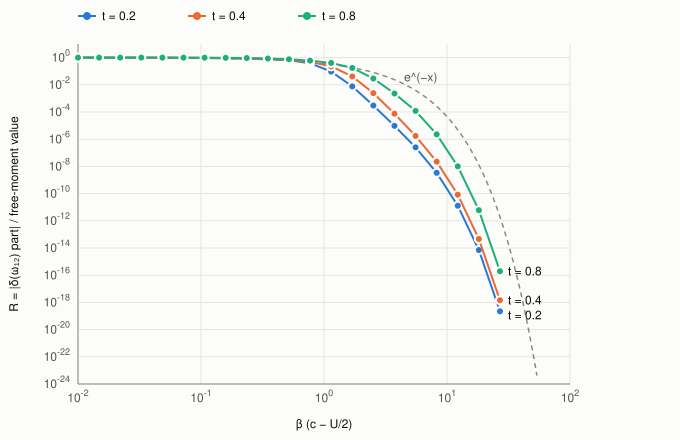

In [17]:
# Static SVG, stdlib only. Validated categorical slots 1-3 (all-pairs CVD-safe); direct labels at the
# line ends because slot 3 is below 3:1 contrast; hover a marker for its values.
function loglog_svg(series; xlab, ylab, xlim, ylim, guide = nothing)
    W, H, l, r, tp, b = 680, 440, 78, 110, 44, 56
    X(x) = l + (log10(x) - log10(xlim[1])) / (log10(xlim[2]) - log10(xlim[1])) * (W - l - r)
    Y(y) = tp + (log10(ylim[2]) - log10(y)) / (log10(ylim[2]) - log10(ylim[1])) * (H - tp - b)
    io = IOBuffer()
    print(io, """<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 $W $H" width="$W" height="$H" font-family="Helvetica, Arial, sans-serif" font-size="12" role="img" aria-label="$ylab against $xlab">
<style>.bg{fill:#fcfcfb}.ink{fill:#0b0b0b}.ink2{fill:#52514e}.grid{stroke:#e4e3df;stroke-width:1}.axis{stroke:#8a8983;stroke-width:1}.guide{stroke:#8a8983;stroke-width:1.5;stroke-dasharray:5 4;fill:none}
@media (prefers-color-scheme: dark){.bg{fill:#1a1a19}.ink{fill:#ffffff}.ink2{fill:#c3c2b7}.grid{stroke:#383835}.axis{stroke:#6f6e69}}</style>
<rect class="bg" x="0" y="0" width="$W" height="$H"/>""")
    for e in ceil(Int, log10(xlim[1])):floor(Int, log10(xlim[2]))
        x = X(10.0^e)
        print(io, """<line class="grid" x1="$x" y1="$tp" x2="$x" y2="$(H-b)"/><text class="ink2" x="$x" y="$(H-b+18)" text-anchor="middle">10<tspan dy="-6" font-size="9">$e</tspan></text>""")
    end
    for e in ceil(Int, log10(ylim[1])):2:floor(Int, log10(ylim[2]))
        y = Y(10.0^e)
        print(io, """<line class="grid" x1="$l" y1="$y" x2="$(W-r)" y2="$y"/><text class="ink2" x="$(l-8)" y="$(y+4)" text-anchor="end">10<tspan dy="-6" font-size="9">$e</tspan></text>""")
    end
    print(io, """<line class="axis" x1="$l" y1="$(H-b)" x2="$(W-r)" y2="$(H-b)"/><line class="axis" x1="$l" y1="$tp" x2="$l" y2="$(H-b)"/>""")
    print(io, """<text class="ink" x="$((l+W-r)/2)" y="$(H-12)" text-anchor="middle">$xlab</text>""")
    print(io, """<text class="ink" transform="translate(18,$((tp+H-b)/2)) rotate(-90)" text-anchor="middle">$ylab</text>""")
    if guide !== nothing
        f, lab = guide
        xs = 10 .^ range(log10(xlim[1]), log10(xlim[2]); length = 120)
        pts = join(["$(X(x)),$(Y(f(x)))" for x in xs if ylim[1] <= f(x) <= ylim[2]], " ")
        print(io, """<polyline class="guide" points="$pts"/>""")
        xg = 4.0
        print(io, """<text class="ink2" x="$(X(xg)+6)" y="$(Y(f(xg)))">$lab</text>""")
    end
    # direct labels at the line ends, pushed apart to at least 15 px
    ends = sort([(Y(s[4][end]), i) for (i, s) in enumerate(series)])
    laby = Dict{Int,Float64}()
    for (k, (y, i)) in enumerate(ends)
        laby[i] = k == 1 ? y : max(y, laby[ends[k-1][2]] + 15)
    end
    for (i, (name, color, xs, ys)) in enumerate(series)
        pts = join(["$(X(x)),$(Y(y))" for (x, y) in zip(xs, ys)], " ")
        print(io, """<polyline points="$pts" fill="none" stroke="$color" stroke-width="2" stroke-linejoin="round"/>""")
        for (x, y) in zip(xs, ys)
            print(io, """<circle cx="$(X(x))" cy="$(Y(y))" r="4" fill="$color" stroke="#fcfcfb" stroke-width="2"><title>$name: x = $(round(x, sigdigits=3)), R = $(round(y, sigdigits=3))</title></circle>""")
        end
        print(io, """<text class="ink" x="$(X(xs[end])+8)" y="$(laby[i]+4)">$name</text>""")
        # legend row above the plot
        lx = l + (i - 1) * 110
        print(io, """<line x1="$lx" y1="16" x2="$(lx+18)" y2="16" stroke="$color" stroke-width="2"/><circle cx="$(lx+9)" cy="16" r="4" fill="$color"/><text class="ink" x="$(lx+24)" y="20">$name</text>""")
    end
    print(io, "</svg>")
    return String(take!(io))
end
colors = Dict(0.2 => "#2a78d6", 0.4 => "#eb6834", 0.8 => "#1baf7a")
series = [("t = $t", colors[t], [r.x for r in scans[t][2] if r.ok], [r.R for r in scans[t][2] if r.ok]) for t in (0.2, 0.4, 0.8)]
display("image/svg+xml", loglog_svg(series; xlab = "β (c − U/2)", ylab = "R = |δ(ω₁₂) part| / free-moment value",
        xlim = (1e-2, 1e2), ylim = (1e-24, 10.0), guide = (x -> exp(-x), "e^(−x)")))

In [18]:
# the decay rate: -d ln|D₁₂| / dβ at large x, against the singlet-triplet gap
println("   t     gap c-U/2    local rate -Δln|D₁₂|/Δβ  (last two scan points)    rate/gap   (gap - rate)·β")
for t in (0.2, 0.4, 0.8)
    gap, rows = scans[t]
    ok = [r for r in rows if r.ok]
    a, b = ok[end-1], ok[end]
    rate = -(log(b.D) - log(a.D)) / (b.β - a.β)
    @printf("  %.1f    %.4f       %.4f  (x = %.1f → %.1f)                        %.3f      %.2f\n", t, gap, rate, a.x, b.x,
            rate / gap, (gap - rate) * sqrt(a.β * b.β))
end

   t     gap c-U/2    local rate -Δln|D₁₂|/Δβ  (last two scan points)    rate/gap   (gap - rate)·β
  0.2    0.0396       0.0378  (x = 18.2 → 26.9)                        0.955      1.00
  0.4    0.1541       0.1472  (x = 18.2 → 26.9)                        0.955      0.99


  0.8    0.5612       0.5345  (x = 18.2 → 26.9)                        0.952      1.05


**Reading D11.** The expectation holds, and more sharply than stated.

* For $\beta(c-U/2)\ll1$ the ratio $R\to1$. The two sites behave as free moments, and the dimer's
  $\delta_{\omega_{12}}$ term is half the atom's, as the D8 transformation predicts.
* The crossover sits at $\beta(c-U/2)\approx1$ for every $t$.
* Beyond it, $|D_{12}|$ itself decays exponentially at a rate set by the singlet–triplet gap. At
  $x\approx20$ the local rate $-d\ln|D_{12}|/d\beta$ is 0.95 of $c-U/2$ for all three $t$. The shortfall times
  $\beta$ is $\approx1$ in each case, so it is a power-law prefactor: $|D_{12}|\approx C\,\beta\,e^{-\beta(c-U/2)}$.
  $e^{-\beta(c-U/2)}$ is the Boltzmann weight of the thermally excited triplet relative to the singlet. Only the
  degenerate triplet can carry a Curie-like $\beta\delta_\omega$ term. The nondegenerate singlet's own diagonal
  cycles are cancelled by $S^{\rm dis}$, since a pure state factorises.
* $R$ falls faster than $e^{-x}$ (dashed guide). The free-moment reference it is divided by keeps growing like
  $\beta^5$ at these frequencies, so $R\sim e^{-x}/x^{\,\sim4\text{–}5}$.

This is an observation from the numerics, not a derivation. It fits the physical picture: once the moments bind,
the static spin susceptibility behind the $\delta$ term changes from Curie to activated.

## Summary

| Check | Result |
|:--|:--|
| operators | canonical anticommutators exact; missing strings caught; $[H,P]=0$ |
| D1 | levels, degeneracies and $Z$ to ≤ 5e-15; shifted weights finite at $\beta=1000$ |
| D2 | $G_k$ vs closed form ≤ 4e-15 at three parameter sets; the three limits; wrong hopping sign caught |
| D3 | $G_{11}$, $G_{12}$ from site operators ≤ 1e-15; $G_{11}$ purely imaginary |
| D4 | $G^R$, $G^A$ ≤ 1e-13 relative; FDT (C4) at all 8 poles, $O(\gamma_0^2)$ |
| D5 | 8 forbidden tuples exactly 0 (≤ 8e-16 unfiltered); allowed tuples finite |
| D6 | $U=0$: $G^{\rm con}$, $F$ ≤ 3e-14 |
| D7 | $F_{\uparrow\downarrow}/U\to\tfrac12\delta$, $F_{\uparrow\uparrow}/U\to0$, to 6e-6 |
| D8 | $t=0$ exact; deviation $\propto t^2$ for $10^{-3}\le t\le10^{-1}$; anomalous and regular branches agree; roundoff $\propto1/t^2$ takes over below $t\approx2\times10^{-4}$ |
| D9 | both crossing forms ≤ 5e-14 |
| D10 | KF selection rule exact, $U=0$ null ≤ 5e-14, Eq. (69) exact |
| D11 | $\delta_{\omega_{12}}$ term: free-moment value for $x\ll1$, cut off as $e^{-\beta(c-U/2)}$ for $x\gg1$ |